# Static and Time-Aware FP8 Quantization for Diffusion Models


| Component | Details |
|-----------|---------|
| **Goal** | Show how to apply static and time-aware FP8 quantization to a diffusion pipeline, then compare quality and speed against bf16 (baseline) and dynamic FP8 |
| **Model** | [black-forest-labs/FLUX.2-klein-base-4B](https://huggingface.co/black-forest-labs/FLUX.2-klein-base-4B) |
| **Dataset** | [nannullna/laion_subset](https://huggingface.co/datasets/nannullna/laion_subset) (`LAION256`) |
| **Optimization Algorithms** | quantizer(`torchao` fp8dq), quantizer(`static_fp8_diffusers`), quantizer(`time_aware_fp8_diffusers`), compiler(`torch_compile`) |
| **Evaluation Metrics** | `latency`, `clip_score` |

This tutorial walks through **Pruna**'s two static FP8 quantizers for `diffusers` pipelines.

1. `static_fp8_diffusers` — weights are quantized once; a **single** activation scale per layer is frozen after calibration.
2. `time_aware_fp8_diffusers` — weights are quantized once; a **per-timestep** activation scale is frozen after calibration.

We compare them to:

- bf16 — the unquantized baseline
- `torchao` fp8dq — dynamic per-forward activation scales

The workflow has two parts.
1. First, we generate a few images from hardcoded prompts and inspect them side by side to confirm that visual quality is preserved.
2. (Extra) We run Pruna's [EvaluationAgent](https://docs.pruna.ai/en/stable/reference/evaluation.html) to measure the latency improvement static algorithms bring. We also calculate the CLIP score, and use it as a proxy to quantify the output quality.

## Prerequisites

- NVIDIA GPU with CUDA - compute capability ≥ 8.9 (Ada Lovelace / Hopper)
- `pruna` installed (`pip install pruna`)
- `diffusers` with Flux2 support
- Hugging Face account with access to Flux2 models

## Getting Started

To install the dependencies, run the following command:


In [1]:
%pip install pruna

/root/dev/prunatree/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


The device is set to the best available option. FP8 kernels need a GPU with compute capability ≥ 8.9. On older hardware the smash step will warn and the quantized matmuls will not run at full speed.

In [2]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
if device == "cuda":
    major, minor = torch.cuda.get_device_capability()
    print(f"Compute capability: {major}.{minor}")
    if (major, minor) < (8, 9):
        print("Warning: FP8 quantization requires compute capability ≥ 8.9.")


Using device: cuda
Compute capability: 9.0


Last, import all the necessary modules.

In [3]:
import gc

import matplotlib.pyplot as plt
from pruna import SmashConfig, smash
from pruna.data.pruna_datamodule import PrunaDataModule
from pruna.engine.utils import safe_memory_cleanup

/root/dev/prunatree/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Skipping import of cpp extensions due to incompatible torch version 2.12.1+cu130 for torchao version 0.16.0             Please see https://github.com/pytorch/ao/issues/2919 for more info


## 1. Load the Model

You need a Hugging Face account with access to the model.


In [ ]:
from huggingface_hub import login

# Replace with your Hugging Face token
HF_TOKEN = "your_token"
login(token=HF_TOKEN)


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


We load the pipeline in `bfloat16`. This 4B model is a good size for comparing FP8 methods - big enough to generate high-quality images, and small enough to smash and evaluate on a single modern GPU.


In [5]:
from diffusers import Flux2KleinPipeline

MODEL_ID = "black-forest-labs/FLUX.2-klein-base-4B"


def load_pipeline():
    """Load a fresh pipeline from the local Hugging Face cache."""
    pipe = Flux2KleinPipeline.from_pretrained(MODEL_ID, torch_dtype=torch.bfloat16)
    pipe.set_progress_bar_config(disable=True)
    return pipe.to(device)


def release_memory():
    gc.collect()
    safe_memory_cleanup()


print("Loading Flux2 pipeline...")
pipe = load_pipeline()
print("Pipeline loaded!")


Loading Flux2 pipeline...


Loading pipeline components...: 100%|██████████| 5/5 [00:00<00:00, 14.35it/s]


Pipeline loaded!


## 2. Define Generation Parameters

Keep the same parameters for every variant to ensure fair comparison.

Change `PROMPT` or add to `PROMPTS` to experiment visually later.

We **do not** enable `torch.compile` for the visual check. Compilation reveals the true speedup an algorithm brings, but requires few slower warmup generations. For a quick visual test, it doesn't bring anything.

In [6]:
PROMPT = "A humanoid robot or cyborg set against a bold red background"
PROMPTS = [PROMPT]

gen_kwargs = dict(
    image=None,
    height=1024,
    width=1024,
    guidance_scale=4.0,
    num_inference_steps=50,
)

SEED = 42

CALIBRATION_BATCHES = 2  # lower this to speed up calibration
CALIBRATION_DATASET = "LAION256"


def get_generator():
    return torch.Generator(device=device).manual_seed(SEED)


def generate_image(model, prompt: str):
    return model(
        prompt=prompt,
        generator=get_generator(),
        **gen_kwargs,
    ).images[0]

## 3. Calibration Data

The static algorithms - `static_fp8_diffusers` and `time_aware_fp8_diffusers` both freeze activation scales following calibration comprising few complete noise-to-image generations.

Attach a dataset to the `SmashConfig` with `add_data`. Pruna ships several image-generation datasets for which a single keyword is enough. We use `LAION256`. Other built-in keywords that work for this task include `COCO`, `DrawBench`, and `PartiPrompts`. Check [Configure Datasets](https://docs.pruna.ai/en/stable/docs_pruna/user_manual/configure.html#configure-datasets) and [Customize Datasets](https://docs.pruna.ai/en/stable/docs_pruna/user_manual/customize_dataset.html) to learn how to provide a custom dataset.

The validation split is used for calibration and `calibration_batches` generations are run.

```python
smash_config = SmashConfig({"static_fp8_diffusers": {"calibration_batches": 4}})
smash_config.add_data("LAION256")
```

## 4. The Quantization Algorithms

The four models in this notebook use the same backbone targeting - linear layers in the transformer / UNet are quantized, while embeddings, norms, and projections are kept in bf16.

### Dynamic

`torchao` with `quant_type="fp8dq"` quantizes weights statically and **recomputes** an activation scale on every forward. That makes it the simplest FP8 baseline - no calibration dataset, and the scale always matches the current tensor. The extra `amax` computation on every layer and step is the cost you pay at inference.

### Static FP8

`static_fp8_diffusers` quantizes weights statically. Activation scales are gathered over a few full denoising trajectories, then **frozen to one scale per layer**. At inference the layer uses the fixed scale, so there is no per-forward `amax`.

### Time-aware FP8

`time_aware_fp8_diffusers` quantizes the weights statically. Activation statistics are stored **per denoising timestep** and looked up at inference. This follows the observation that input distributions shift across the noise schedule ([Temporal Dynamic Quantization](https://arxiv.org/abs/2306.02316)). 


## 5. Smash and Compare Images

We smash a freshly loaded pipeline\* using each quantization algorithm and generate image(s) with the hardcoded prompt(s).

\*Reloading with `from_pretrained` uses the local Hugging Face cache, so later loads do not re-download the weights.

In [7]:
VARIANT_LABELS = [
    "BF16\n(baseline)",
    "TorchAO FP8-DQ\n(dynamic scale)",
    "Static FP8\n(single scale)",
    "Time-aware FP8\n(per-timestep scale)",
]


def make_smash_config(configuration: dict) -> SmashConfig:
    smash_config = SmashConfig(configuration)
    # Disable saving to avoid writing a full pipeline copy to disk.
    smash_config.disable_saving();
    return smash_config


def attach_calibration_data(smash_config: SmashConfig) -> SmashConfig:
    smash_config.add_data(CALIBRATION_DATASET)
    smash_config.data.limit_datasets(16)
    return smash_config


def smash_torchao_fp8dq(model):
    smash_config = make_smash_config({"torchao": {"quant_type": "fp8dq"}})
    return smash(model=model, smash_config=smash_config)


def smash_static_fp8(model):
    smash_config = make_smash_config(
        {"static_fp8_diffusers": {"calibration_batches": CALIBRATION_BATCHES}}
    )
    attach_calibration_data(smash_config)
    return smash(model=model, smash_config=smash_config)


def smash_time_aware_fp8(model):
    smash_config = make_smash_config(
        {
            "time_aware_fp8_diffusers": {
                "calibration_batches": CALIBRATION_BATCHES,
                "calibration_num_inference_steps": gen_kwargs["num_inference_steps"],
            }
        }
    )
    attach_calibration_data(smash_config)
    return smash(model=model, smash_config=smash_config)


images_by_prompt = {prompt: [] for prompt in PROMPTS}

print("--- BF16 baseline ---")
for prompt in PROMPTS:
    images_by_prompt[prompt].append(generate_image(pipe, prompt))
del pipe
release_memory()

quant_builders = [
    ("TorchAO FP8-DQ", smash_torchao_fp8dq),
    ("Static FP8", smash_static_fp8),
    ("Time-aware FP8", smash_time_aware_fp8),
]

for name, builder in quant_builders:
    print(f"--- {name} ---")
    quantized = builder(load_pipeline())
    for prompt in PROMPTS:
        images_by_prompt[prompt].append(generate_image(quantized, prompt))
    del quantized
    release_memory()

print("Visual generations complete.")


--- BF16 baseline ---
--- TorchAO FP8-DQ ---


Loading pipeline components...: 100%|██████████| 5/5 [00:00<00:00, 13.92it/s]
INFO - Using best available device: 'cuda'
INFO - Disabling the preparation of saving, smashed model will not be saveable.
WARNING - torchao has strict version compatibility requirements with torch. If you encounter crashes when using torchao, ensure that your torch and torchao versions are compatible, as documented in the torchao compatibility table: https://github.com/pytorch/ao/issues/2919#issue-3375688762
INFO - Determined algorithm order: torchao
INFO - Starting torchao...
INFO - torchao was applied successfully.


--- Static FP8 ---


Loading pipeline components...: 100%|██████████| 5/5 [00:00<00:00, 14.17it/s]
INFO - Using best available device: 'cuda'
INFO - Disabling the preparation of saving, smashed model will not be saveable.
INFO - Loaded only training, splitting train 80/10/10 into train, validation and test...
INFO - Testing compatibility with image_generation_collate...
INFO - Determined algorithm order: static_fp8_diffusers
INFO - Starting static_fp8_diffusers...
INFO - Using best available device: 'cuda'
INFO - static_fp8_diffusers calibrated over 2 batch(es).
INFO - static_fp8_diffusers was applied successfully.


--- Time-aware FP8 ---


Loading pipeline components...: 100%|██████████| 5/5 [00:00<00:00, 14.64it/s]
INFO - Using best available device: 'cuda'
INFO - Disabling the preparation of saving, smashed model will not be saveable.
INFO - Loaded only training, splitting train 80/10/10 into train, validation and test...
INFO - Testing compatibility with image_generation_collate...
INFO - Determined algorithm order: time_aware_fp8_diffusers
INFO - Starting time_aware_fp8_diffusers...
INFO - Using best available device: 'cuda'
INFO - Bin edges: tensor([0.1870, 0.2832, 0.3613, 0.4258, 0.4814, 0.5293, 0.5723, 0.6094, 0.6406,
        0.6680, 0.6914, 0.7148, 0.7363, 0.7559, 0.7734, 0.7891, 0.8027, 0.8164,
        0.8301, 0.8398, 0.8496, 0.8594, 0.8691, 0.8789, 0.8867, 0.8945, 0.9004,
        0.9062, 0.9160, 0.9238, 0.9297, 0.9355, 0.9395, 0.9453, 0.9512, 0.9551,
        0.9590, 0.9629, 0.9668, 0.9707, 0.9746, 0.9785, 0.9824, 0.9863, 0.9902,
        0.9941, 0.9980], device='cuda:0')
INFO - time_aware_fp8_diffusers calibrate

Visual generations complete.


The four images should remain close in subject, composition, and prompt alignment. However, they will not be identical. Round-to-nearest symmetric quantization does not optimize _reproducing_ the sampler trajectory. Thus, it is appropriate method for quality-preservation, but it might not be the best for fidelity.


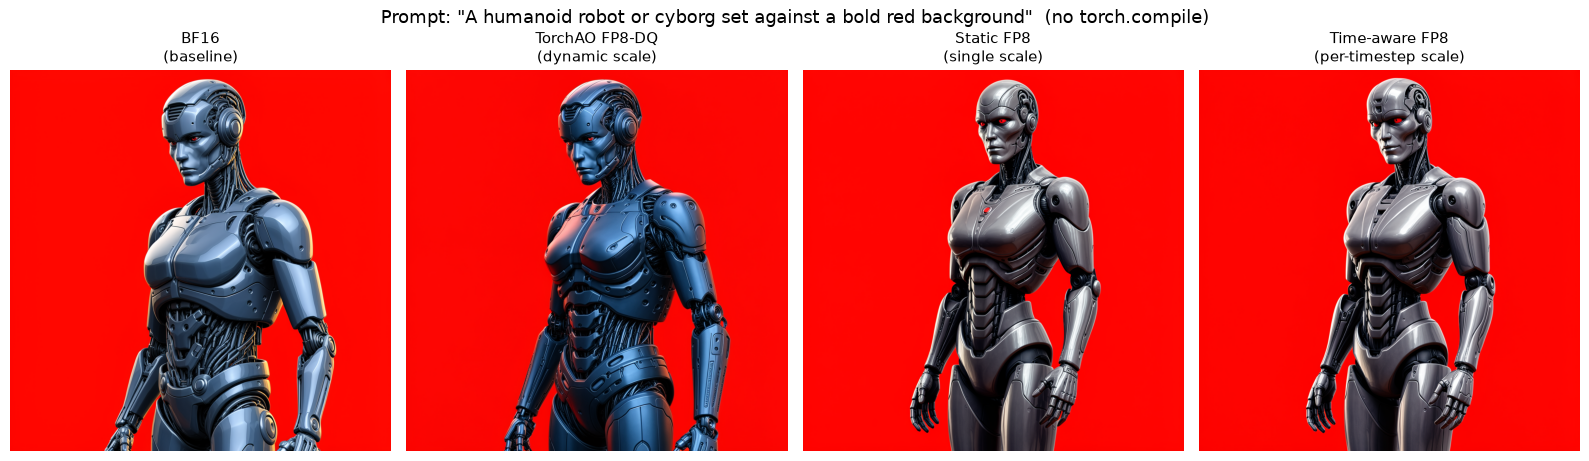

In [8]:
n_prompts = len(PROMPTS)
fig, axes = plt.subplots(n_prompts, 4, figsize=(16, 4.5 * n_prompts))
if n_prompts == 1:
    axes = [axes]

for row, prompt in enumerate(PROMPTS):
    for col, (image, title) in enumerate(zip(images_by_prompt[prompt], VARIANT_LABELS)):
        axes[row][col].imshow(image)
        axes[row][col].set_title(title, fontsize=11)
        axes[row][col].axis("off")

title = f'Prompt: "{PROMPTS[0]}"' if n_prompts == 1 else "FP8 variants vs bf16"
plt.suptitle(f"{title}  (no torch.compile)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## 6. Cleanup

In [9]:
del images_by_prompt
release_memory()

## Conclusion

In this tutorial we explored the Pruna's static FP8 quantizers and applied them to Flux2 Klein 4B. We also compared how the quantized models behave compared to the baseline and the variant quantized through TorchAO dynamic FP8. You can adapt the `SmashConfig`, calibration set, and prompts to your pipeline, or reach out on [Discord](https://discord.gg/JFQmtFKCjd) for questions.


## (Extra) Evaluate with the EvaluationAgent

_This evaluation takes more time - e.g., 30 minutes on H100, due to the compile-mode setting required by torchao._

This stage smashes each variant with `torch.compile` to reveal the true speed up each algorithm brings.

We use `torch_compile_mode="max-autotune-no-cudagraphs"`, which is the recommended mode for TorchAO FP8. The first few evaluation batches include compile warmup. `LatencyMetric`'s `n_warmup_iterations` discards them so the reported latency is the steady-state number.

Metrics:

- **`latency`** — average time per batch
- **`clip_score`** — CLIP prompt–image alignment (quality proxy)

The evaluation dataset is `LAION256`. Increase `limit_datasets` and `n_iterations` for a more stable measurement.

In [ ]:
from pruna.evaluation.evaluation_agent import EvaluationAgent
from pruna.evaluation.metrics import LatencyMetric, TorchMetricWrapper
from pruna.evaluation.task import Task

COMPILE_KWARGS = {"mode": "max-autotune-no-cudagraphs"}
EVAL_INFERENCE_ARGS = {
    "image": None,
    "height": gen_kwargs["height"],
    "width": gen_kwargs["width"],
    "guidance_scale": gen_kwargs["guidance_scale"],
    "num_inference_steps": gen_kwargs["num_inference_steps"],
}

eval_datamodule = PrunaDataModule.from_string("LAION256")
eval_datamodule.limit_datasets(8)

metrics = [
    LatencyMetric(n_iterations=5, n_warmup_iterations=2),
    TorchMetricWrapper("clip_score"),
]
task = Task(metrics, datamodule=eval_datamodule, device=device)
eval_agent = EvaluationAgent(task)


def smash_and_evaluate(label: str, configuration: dict, needs_calibration: bool = False):
    print(f"\n=== Evaluating {label} ===")
    smash_config = make_smash_config(configuration)
    if needs_calibration:
        attach_calibration_data(smash_config)
    model = smash(model=load_pipeline(), smash_config=smash_config)
    model.inference_handler.model_args.update(EVAL_INFERENCE_ARGS)
    results = eval_agent.evaluate(model)
    del model
    release_memory()
    return results


results_by_variant = {}
results_by_variant["bf16"] = smash_and_evaluate(
    "bf16 + torch.compile",
    {"torch_compile": COMPILE_KWARGS},
)
results_by_variant["fp8dq"] = smash_and_evaluate(
    "torchao fp8dq + torch.compile",
    {"torchao": {"quant_type": "fp8dq"}, "torch_compile": COMPILE_KWARGS},
)
results_by_variant["static"] = smash_and_evaluate(
    "static_fp8_diffusers + torch.compile",
    {
        "static_fp8_diffusers": {"calibration_batches": CALIBRATION_BATCHES},
        "torch_compile": COMPILE_KWARGS,
    },
    needs_calibration=True,
)
results_by_variant["time-aware"] = smash_and_evaluate(
    "time_aware_fp8_diffusers + torch.compile",
    {
        "time_aware_fp8_diffusers": {
            "calibration_batches": CALIBRATION_BATCHES,
            "calibration_num_inference_steps": gen_kwargs["num_inference_steps"],
        },
        "torch_compile": COMPILE_KWARGS,
    },
    needs_calibration=True,
)


We can now review latency and CLIP score across the four compiled models. Lower latency is better. Higher CLIP score is better. We expect the compiled FP8 variants to improve latency, with CLIP scores remaining in the same range. Dynamic FP8 spends extra time on per-forward scales, while static and time-aware avoid that cost post-calibration. If CLIP drops sharply, try more `calibration_batches`, a calibration set closer to your prompts, or leave sensitive modules out via `target_modules`.

In [ ]:
from IPython.display import Markdown, display  # noqa

DISPLAY_NAMES = {
    "bf16": "BF16",
    "fp8dq": "TorchAO FP8-DQ",
    "static": "Static FP8",
    "time-aware": "Time-aware FP8",
}


def make_comparison_table(named_results):  # noqa
    names = list(named_results.keys())
    header = "| Metric | " + " | ".join(DISPLAY_NAMES[n] for n in names) + " |\n"
    header += "|" + "-----|" * (len(names) + 1) + "\n"
    first = named_results[names[0]]
    rows = []
    for i, metric in enumerate(first):
        cells = [metric.name]
        for name in names:
            result = named_results[name][i]
            units = f" {result.metric_units}" if result.metric_units else ""
            cells.append(f"{result.result:.4f}{units}")
        rows.append("| " + " | ".join(cells) + " |")
    return header + "\n".join(rows)


display(Markdown(make_comparison_table(results_by_variant)))
